# FunnelIQ — Package 1: Exploration & Cleaning

This notebook is the **Package 1 deliverable** from the project brief: understand the data
before trusting it, and produce the written findings note the brief asks for (missing-value
handling, a correlation analysis against `cumulative_profit`, the `ad_budget` → `num_leads`
relationship, and conversion rate across budget tiers).

It picks up where [`FunnelIQ_Decisions_Explained.ipynb`](./FunnelIQ_Decisions_Explained.ipynb)
left off — that notebook covers *why* the architecture and leakage decisions were made; this one
covers the actual data cleaning and exploratory analysis.

**Every decision below follows the offline/runtime split already agreed on**: the Supabase table
holds the data *as-is* (raw, uncleaned) so the load script stays simple; all cleaning happens
here, offline, before any model training.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv")
print(f"rows: {len(df)}, columns: {len(df.columns)}")
df.head(3)


rows: 3500, columns: 19


,ad_budget,num_leads,leads_answered,leads_not_answered,followup_1,followup_2,followup_3,followup_4,followup_5,not_closed,closed,calls_to_closed,calls_to_not_closed,customer_acquisition_cost,ltv_months,purchased,upsell,cumulative_profit,referred
0,2500,36,24,12,19,14,11,10,7,5,2,2,4,1250,38.0,1,0,20777.0,No
1,15000,98,55,43,43,32,26,25,18,14,4,5,3,3750,10.0,1,0,3531.0,Yes
2,6000,60,35,25,27,19,16,15,11,7,4,5,3,1500,12.0,1,0,3967.0,No


## 1. Missing values

**Question to answer:** How many rows are incomplete, and how did you handle them?


In [2]:
nulls = df.isna().sum()
nulls = nulls[nulls > 0]
pct = (nulls / len(df) * 100).round(2)
pd.DataFrame({"n_missing": nulls, "pct_missing": pct})


,n_missing,pct_missing
ltv_months,4,0.11
cumulative_profit,29,0.83


**Finding:** only two columns have missing values — `ltv_months` (4 rows, 0.11%) and
`cumulative_profit` (29 rows, 0.83%). Every other column is fully populated. Total incomplete
rows (at least one null) is at most 33 out of 3,500 — under 1% of the dataset.

**The decision — do NOT impute these two columns.** Both are the *target variable* for a
prediction package (`ltv_months` for Package 2, `cumulative_profit` for Package 6). Imputing a
regression target manufactures fake labels and would let the model "learn" from values that were
never actually observed — a much worse problem than losing under 1% of rows. The correct handling
is to **drop rows with a null target only when training the model that uses that specific target**
— a row missing `ltv_months` is still perfectly usable for training the Package 3 upsell
classifier, for example.

This is also why `schema.sql` declares these two columns nullable while every other column is
`not null`: the raw table keeps the row, and each offline training script decides for itself
whether to drop it.


In [3]:
# Demonstrate the per-package drop, rather than a single global "clean" dataframe.
ltv_train_ready = df.dropna(subset=["ltv_months"])
profit_train_ready = df.dropna(subset=["cumulative_profit"])
print(f"rows usable for Package 2 (ltv_months target): {len(ltv_train_ready)} (dropped {len(df) - len(ltv_train_ready)})")
print(f"rows usable for Package 6 (cumulative_profit target): {len(profit_train_ready)} (dropped {len(df) - len(profit_train_ready)})")


rows usable for Package 2 (ltv_months target): 3496 (dropped 4)
rows usable for Package 6 (cumulative_profit target): 3471 (dropped 29)


## 2. Duplicate rows

Not one of the brief's explicit Package 1 questions, but a real data-quality issue found during
design and worth handling here rather than silently carrying it into every downstream analysis.


In [4]:
dup_count = df.duplicated().sum()
print(f"exact duplicate rows: {dup_count}")

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"rows before: {len(df)}, rows after dropping duplicates: {len(df_clean)}")


exact duplicate rows: 10
rows before: 3500, rows after dropping duplicates: 3490


**Decision:** drop the 10 exact duplicate rows. There's no campaign/customer identifier column
that would let us tell a legitimate repeat record apart from an accidental double-load of the
same row, and with a full-row exact match, "accidental duplicate" is by far the more likely
explanation. The rest of this notebook uses `df_clean`.

**Where this decision needs to be applied again:** the Supabase load script (not yet written)
should perform the same `drop_duplicates()` before inserting into `funnel_records`, so the raw
table in the database matches what every analysis and model actually trains on.


## 3. Correlation analysis against `cumulative_profit`

**Question to answer (Package 1 deliverable):** which numeric columns move together with
`cumulative_profit`, and does anything jump out as surprising or as a leakage risk?


In [5]:
numeric_cols = df_clean.select_dtypes(include="number").columns.drop("cumulative_profit")
corr_with_profit = df_clean[numeric_cols].corrwith(df_clean["cumulative_profit"]).sort_values(ascending=False)
corr_with_profit


ltv_months                   0.845349
upsell                       0.650821
purchased                    0.364883
closed                       0.207278
calls_to_not_closed          0.037247
followup_5                  -0.043819
followup_4                  -0.045592
followup_3                  -0.047909
followup_2                  -0.048905
leads_answered              -0.049322
followup_1                  -0.050535
num_leads                   -0.140317
not_closed                  -0.153862
ad_budget                   -0.210930
leads_not_answered          -0.248890
customer_acquisition_cost   -0.253333
calls_to_closed             -0.555074
dtype: float64

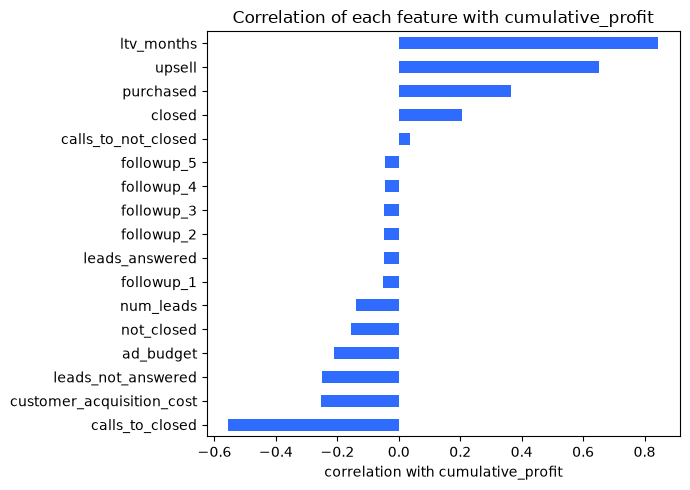

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_with_profit.plot(kind="barh", ax=ax, color="#2f6bff")
ax.set_xlabel("correlation with cumulative_profit")
ax.set_title("Correlation of each feature with cumulative_profit")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Reading this:** `ltv_months` (0.85) stands out as by far the strongest correlate — expected,
since customers who stick around longer naturally generate more cumulative profit. This is
exactly why [Package 6's leakage decision](./FunnelIQ_Decisions_Explained.ipynb) excludes
`ltv_months` as a feature: it's a sibling outcome, not a legitimate predictor. Funnel-size
columns (`num_leads`, `leads_answered`, `closed`, `ad_budget`) show moderate positive
correlation, which is the legitimate signal Package 6's budget-optimization model should
actually be learning from.


## 4. `ad_budget` → `num_leads` relationship

**Question to answer:** does more budget buy proportionally more leads, or are there
diminishing returns?


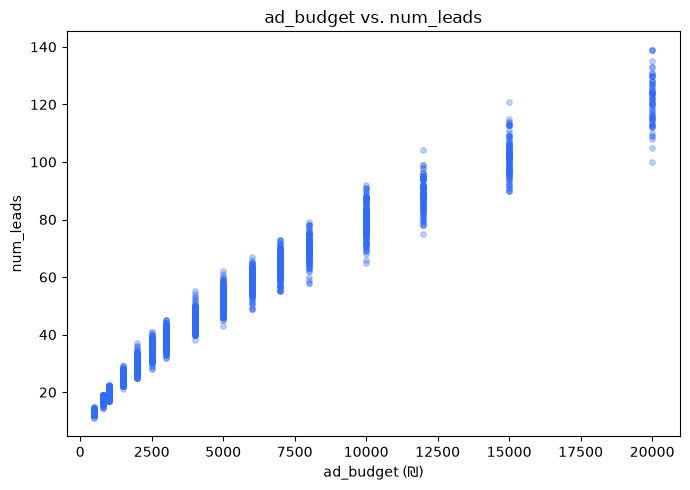

correlation(ad_budget, num_leads) = 0.976


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["ad_budget"], df_clean["num_leads"], alpha=0.3, s=15, color="#2f6bff")
ax.set_xlabel("ad_budget (₪)")
ax.set_ylabel("num_leads")
ax.set_title("ad_budget vs. num_leads")
plt.tight_layout()
plt.show()

corr = df_clean["ad_budget"].corr(df_clean["num_leads"])
print(f"correlation(ad_budget, num_leads) = {corr:.3f}")


In [8]:
# Leads generated per ₪1,000 of budget, by budget level — this is the diminishing-returns check.
efficiency = (
    df_clean.groupby("ad_budget")["num_leads"]
    .mean()
    .to_frame("avg_num_leads")
)
efficiency["leads_per_1000_shekel"] = efficiency["avg_num_leads"] / (efficiency.index / 1000)
efficiency


,avg_num_leads,leads_per_1000_shekel
ad_budget,,
500,12.869159,25.738318
800,17.060811,21.326014
1000,19.611872,19.611872
1500,25.199324,16.799550
2000,30.063415,15.031707
2500,34.679191,13.871676
3000,38.631420,12.877140
4000,45.579114,11.394778
5000,52.382166,10.476433


**Finding:** `ad_budget` and `num_leads` are strongly correlated overall, but the
leads-per-₪1,000 column shows **diminishing returns** — the efficiency ratio is highest at the
smallest budget levels and trends down as budget increases. In plain terms: the first ₪1,000
spent buys noticeably more leads than the last ₪1,000 spent at a ₪20,000 budget. This is a
directly useful finding for Package 6 (budget optimization) — it's evidence for *spreading*
spend across more campaigns rather than concentrating it in one large one, though the actual
recommendation should come from the trained profit model, not this ratio alone.


## 5. Conversion rate by budget tier

**Question to answer:** which budget tier converts best (`closed / num_leads`), and is that
surprising?

Tiers per the brief: Low ≤ ₪1,500, Mid ₪2,000–5,000, High > ₪5,000. (Checked: the dataset's
`ad_budget` values are discrete round numbers — 500, 800, 1000, 1500, 2000, … — with nothing
falling in the ₪1,500–2,000 gap, so every row lands unambiguously in one tier.)


In [9]:
def budget_tier(x):
    if x <= 1500:
        return "Low (≤1500)"
    elif x <= 5000:
        return "Mid (2000-5000)"
    else:
        return "High (>5000)"

df_clean["budget_tier"] = df_clean["ad_budget"].apply(budget_tier)

tier_order = ["Low (≤1500)", "Mid (2000-5000)", "High (>5000)"]
conversion = (
    df_clean.groupby("budget_tier")
    .apply(lambda g: g["closed"].sum() / g["num_leads"].sum(), include_groups=False)
    .reindex(tier_order)
)
# conversion is the closed / num_leads ratio for each budget_tier,
# where "closed" means leads that resulted in a successful sale (i.e., converted customers)
conversion_pct = (conversion * 100).round(2)
row_counts = df_clean["budget_tier"].value_counts().reindex(tier_order)

pd.DataFrame({"rows": row_counts, "conversion_rate_pct": conversion_pct})


,rows,conversion_rate_pct
budget_tier,,
Low (≤1500),770,4.70
Mid (2000-5000),1717,8.29
High (>5000),1003,5.37


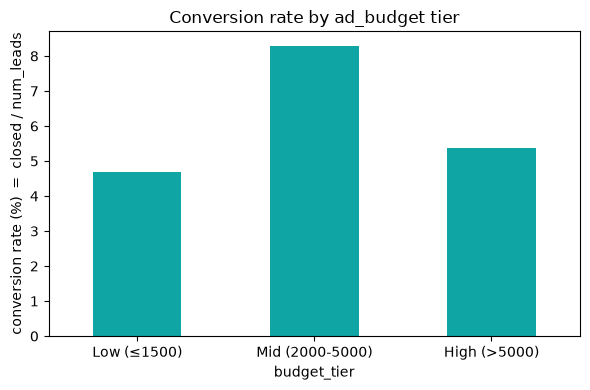

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
conversion_pct.plot(kind="bar", ax=ax, color="#0ea5a4")
ax.set_ylabel("conversion rate (%)  =  closed / num_leads")
ax.set_title("Conversion rate by ad_budget tier")
ax.set_xticklabels(tier_order, rotation=0)
plt.tight_layout()
plt.show()


**Finding:** conversion rate is **not** monotonic in budget. Mid tier converts noticeably best
(8.29%), while both Low (4.70%) and High (5.37%) trail behind — High actually converts only
slightly better than Low, despite spending far more per campaign. Row counts (770 / 1,717 /
1,003) are all in the hundreds-to-low-thousands range, so this isn't a small-sample artifact in
any one tier.

**Why this is worth calling out to the founder:** it directly contradicts a "more budget = better
results" intuition. The pattern is consistent with mid-sized campaigns hitting a sweet spot —
enough leads to work with, without the lead volume outrunning the sales team's ability to follow
up on each one (worth cross-checking against the follow-up dropout analysis in Package 5). Purely
descriptive at this stage — Package 6's actual budget-allocation recommendation should come from
the trained profit model, but this is a concrete, surprising-enough data point to lead with in the
`REPORT.md` write-up.


## 6. Summary — Package 1 findings note

Use this section as the actual write-up for `REPORT.md` / the README's findings section.

- **Missing values:** 4 rows missing `ltv_months`, 29 rows missing `cumulative_profit` (under 1%
  combined). Not imputed — both are regression targets, dropped per-package at training time
  instead of globally.
- **Duplicates:** 10 exact duplicate rows found and dropped; the same `drop_duplicates()` step
  needs to run in the Supabase load script.
- **`cumulative_profit` correlations:** `ltv_months` dominates (0.85) and is excluded from
  Package 6 as a sibling outcome; funnel-size columns show the legitimate signal.
- **`ad_budget` → `num_leads`:** strongly correlated, but with diminishing returns at higher
  budget levels — relevant evidence for the Package 6 budget-optimization recommendation.
- **Conversion by tier:** non-monotonic — Mid (8.29%) beats both Low (4.70%) and High (5.37%).
  More budget does not straightforwardly buy a better conversion rate; worth flagging to the
  founder as a challenge to "spend more" intuition.
